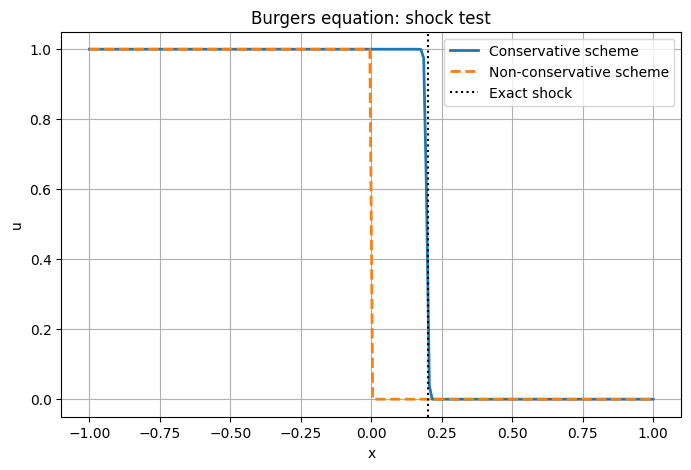

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Nx = 200
x = np.linspace(-1, 1, Nx)
dx = x[1] - x[0]

T = 0.4
CFL = 0.8
dt = CFL * dx
Nt = int(T / dt)

gamma = dt / dx

def initial_condition(x):
    return np.where(x <= 0, 1.0, 0.0)

def conservative_step(u):
    u_new = u.copy()
    for i in range(1, len(u)):
        u_new[i] = u[i] - gamma * 0.5 * (u[i]**2 - u[i-1]**2)
    u_new[0] = u_new[1] 
    return u_new

def nonconservative_step(u):
    u_new = u.copy()
    for i in range(1, len(u)):
        u_new[i] = u[i] - gamma * u[i] * (u[i] - u[i-1])
    u_new[0] = u_new[1]
    return u_new

u_cons = initial_condition(x)
u_noncons = initial_condition(x)

for n in range(Nt):
    u_cons = conservative_step(u_cons)
    u_noncons = nonconservative_step(u_noncons)

shock_pos = 0.5 * T 


plt.figure(figsize=(8,5))
plt.plot(x, u_cons, label="Conservative scheme", linewidth=2)
plt.plot(x, u_noncons, '--', label="Non-conservative scheme", linewidth=2)
plt.axvline(shock_pos, color='k', linestyle=':', label='Exact shock')
plt.legend()
plt.xlabel("x")
plt.ylabel("u")
plt.title("Burgers equation: shock test")
plt.grid()
plt.show()